# Linkage Optimization Demo

<div style="font-size: small;">
License Terms:  
These Python demos are licensed under a <a href="https://creativecommons.org/licenses/by-nc-nd/4.0/">Creative Commons Attribution-NonCommercial-NoDerivatives 4.0 International License</a>. They are intended for educational use only in ME 498/598: Applied AI for Engineering and Design at the University of Illinois Urbana-Champaign. You may not share or distribute them publicly, use them for commercial purposes, or provide them to industry or other entities without permission from the instructor (regnwttr@illinois.edu).
</div>

 In this demo we will use both **gradient-based optimization** and **evolutionary optimization (a genetic algorithm)** to solve a linkage path-synthesis design problem. This notebook is also the on-ramp to Challenge Problem 1 (CP1), which tackles a harder version of the same problem.

## Optimization: A Quick Recap
In optimization our objective is to find the best possible solution for a given objective function. Often, however we also have some constraints that we might want to meet as well. More concretely, an optimization problem generally has three main components:

- **Design Variables**, $\mathbf x$: A set of design variables, describing the parameters of the underlying problem. For example, imagine you are designing a bike like the ones in the visualization demo, then the design variables would be all those variables we saw describing a bike!
- **Objective Function:**, $f(\textbf x)$: A function of the design variables that provides a measure of performance. Our aim is to find the best $\textbf x$ that either minimizes this function or maximizes it. For example we may want the lightest possible bike. We would have to find the best possible $\textbf x$ that minimizes the weight of the bike.
- **Constraints**, $\Omega$: Constraints are described as a set, denoted as $\Omega$ here, which the design variables must be inside to be considered valid. For example, in our example of minimizing the bike weight, we can just set all parameters to 0 and deliver air 🙃, with no weight, but that would not be a bike. The point of having constraints is to find the best possible $\mathbf x \in \Omega$ which results in a valid design, not just the design that optimized $f(\textbf x)$. Note that the set $\Omega$ in many cases is described as a set of inequality and equality constraints on functions of $\mathbf x$, for example $g(\mathbf x)\leq0,\;h(\mathbf x)=0,\; l\leq\mathbf x\leq u,\; \ldots$


Often we use the following mathematical notation to describe optimization problems:

$$
\begin{align}
    \min_{\mathbf x} &f(\mathbf x)\\
    \text{subject to}\quad & l\leq \mathbf x \leq u\\
    &h(\mathbf x)=0\\
    &g(\mathbf x)\leq0\\
    &\ldots
\end{align}
$$

More compactly:

$$
\begin{align}
    \min_{\mathbf x} &f(\mathbf x)\\
    \text{subject to}\quad & \mathbf x \in \Omega
\end{align}
$$

We talked about a few different ways of how optimization can be done in practice. In this notebook we will demonstrate two approaches for optimization. First we will walk through a **gradient-based optimization** approach, then we will follow that up with an application of the **genetic algorithm**.

## Design Representation, Objectives, and Constraints

In this demonstration we focus on the **linkage synthesis problem**: designing a linkage mechanism that traces a target curve. To solve this we need to answer: how many joints do we need? How many linkages? Which joints do they connect? Which joints are fixed in space? What are the initial joint positions?

We also need the mechanism to move with only one actuator, and for that actuator to be able to complete a full rotation without the mechanism locking.

Going back to the optimization components:

- **Design Variables**, $\mathbf x$: number of joints, joint types (fixed or not), number of linkages, which joints they connect, and initial joint positions.
- **Objective Function**, $f(\mathbf x)$: how closely the curve traced by the mechanism resembles the target curve.
- **Constraints**, $\Omega$: the mechanism must have exactly one degree of freedom, and it must not lock during a full rotation of the actuator.

**But how do we handle these computationally?**

### Representing Mechanisms
We represent linkage mechanisms as graphs: a set of nodes ($N = \{0,1,\ldots,n-1\}$) and a set of edges describing how nodes connect ($E = \{(0,1), (1,3), \ldots\}$). Nodes also carry features (e.g. initial position).

<div width="100%"><img src="linkage_simple.png" alt="Path Synthesis Problem" width="45%" style="margin:auto;display:block"></div>

The example above has 5 joints ($N=\{0,1,2,3,4\}$) and edges $E=\{(0,1),(1,3),(1,4),(2,3),(3,4)\}$. Node 0 is a fixed ground pivot, node 1 is the crank tip (driven, moving in a circle), node 2 is a second fixed ground pivot, and node 4 is the coupler point whose traced path (dashed blue loop) is what we're actually trying to shape.

**Convention:** nodes 0 and 1 always form the motor-driven crank (dashed yellow above) &mdash; node 0 fixed, node 1 free, connected by a link, at $(0.0,0.0)$ and $(0.0,1.0)$ respectively, driven by the motor &mdash; a canonical, unit-length crank. Thus, our representation will just describe the *rest of the linkage*:

- **Initial Positions** `x0`: an $(N-2) \times 2$ array holding the initial positions of the *non-crank* joints, nodes 2 through $N-1$.
- **Linkages** `edges`: an $(E-1) \times 2$ array of integer node-index pairs, one row per linkage, other than the crank's own link $(0,1)$.
- **Fixed Joints** `fixed_joints`: the indices of the nodes that are fixed in space, other than node 0. 

Every function in the codebase (`MechanismSolver`, `MechanismVisualizer`, `Tools`, `DifferentiableTools`, `MechanismRandomizer`) already assumes this mechanism representation. Let's define a mechanism in Python and see how this works:

In [ ]:
#First some imports and setup
import os
os.environ["JAX_PLATFORMS"] = "cpu"  # Force CPU for JAX. If you have a CUDA GPU and want to try it, remove
                                      # this line and pass device='gpu' below -- but note JAX's GPU support
                                      # is Linux-only 

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm, trange

from LINKS.Visualization import MechanismVisualizer
from LINKS.Kinematics import MechanismSolver
from LINKS.Geometry import CurveEngine
from LINKS.Optimization import Tools, DifferentiableTools

# deterministic random numbers
np.random.seed(0)

Now let's define our mechanism:

In [2]:
# Define the free joint positions (nodes 2 onward). Nodes 0 and 1 are the fixed crank
# (0,0)/(0,1) and are handled internally -- they are never part of x0.
x0 = np.array([[3.0, 0.0],
               [3.0, 2.0],
               [1.0, 3.0]])

# Define the connectivity of the mechanism, other than the crank's own link (0,1), which
# is implicit
edges = np.array([[1,3],
                  [1,4],
                  [2,3],
                  [3,4]])

# Define the fixed nodes, other than node 0 (the crank's ground pivot), which is implicit.
# Node 1 can't be fixed, and is presumed to be free, as it is the driven node. 
fixed_joints = np.array([2])

Let's visualize the mechanism. We have provided a visualizer to assist with this. We instantiate the visualizer, then pass in the variables representing the linkage we have just defined.

<Axes: >

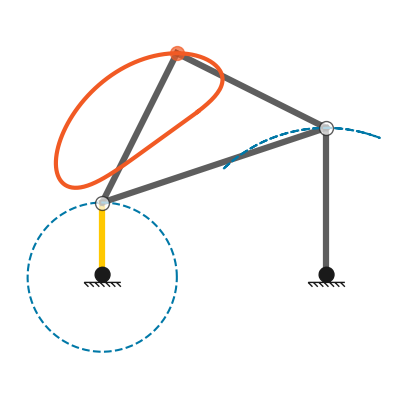

In [3]:
# make an instance of the visualizer
visualizer = MechanismVisualizer()
plt.figure(figsize=(5,5))
visualizer(x0, edges, fixed_joints, ax=plt.gca())

### The Objective Function
Comparing two curves involves aligning them (translation, rotation, and choosing where each traces "starts") before measuring a distance. The `CurveEngine` class handles this alignment for us.

In this demo, our goal is to optimize a mechanism to trace the curve below:

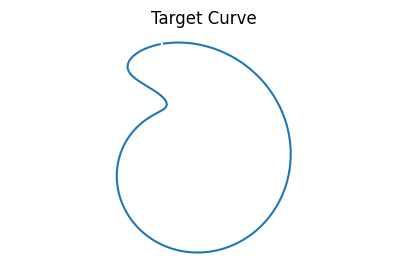

In [4]:
# load the target curve
target_curve = np.load('SampleCurves/samples.npy')[37]

plt.figure(figsize=(5,3))
plt.plot(target_curve[:,0], target_curve[:,1])
plt.title('Target Curve')
plt.axis('equal')
plt.axis('off')
plt.show()

Now let's see how well the curve produced by our mechanism matches this curve. We can isolate the curve generated by our linkage by creating an instance of the provided `MechanismSolver` class, and passing in the variables defining our linkage, as so.   

(np.float64(-0.7326428830623627),
 np.float64(1.7232135474681853),
 np.float64(1.1068823695182801),
 np.float64(3.0901212334632873))

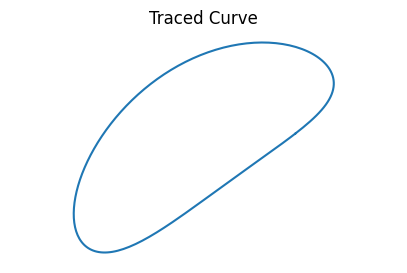

In [5]:
# make an instance of the solver to get the mechanism's curves
# the visualizer above used an instance of this solver class internally
solver = MechanismSolver(device='cpu')

# solve and get the coupler curve from node 4 (the last node)
curves = solver(x0, edges, fixed_joints)
curve = curves[-1]

plt.figure(figsize=(5,3))
plt.plot(curve[:,0], curve[:,1])
plt.title('Traced Curve')
plt.axis('equal')
plt.axis('off')

These two curves are not aligned with each other. So we first have to align them before we can measure their distance. The `CurveEngine` class provides `optimal_alignment` (and a `visualize_alignment` helper) to do this for us.

Distance between curves: 1.4997


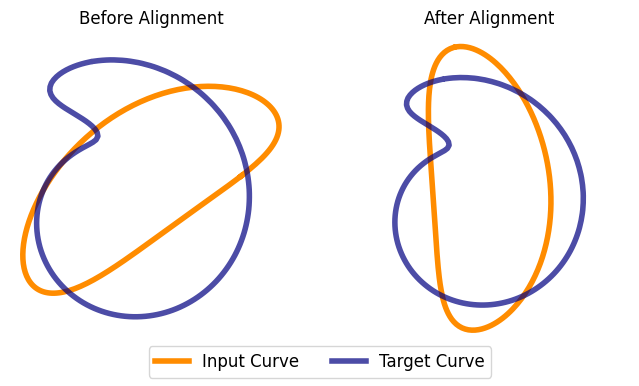

In [6]:
# make an instance of the curve processor (scale-invariant: each curve is compared by shape, not absolute size)
curve_processor = CurveEngine(normalize_scale=True, device='cpu')

# align and measure the distance between the two curves
aligned_curve, aligned_target_curve, distance = curve_processor.optimal_alignment(curve, target_curve)

print(f'Distance between curves: {float(distance):.4f}')

curve_processor.visualize_alignment(curve, target_curve)

### Constraints in Practice
Recall from the recap above: a valid mechanism needs **exactly one degree of freedom**, and it must **not lock** while the crank completes a full rotation. These aren't just abstract rules &mdash; let's see exactly what they look like in code.

In [7]:
# A well-formed mechanism has exactly one degree of freedom. Let's break that two ways:
# adding a redundant linkage (over-constrained), and removing one (under-constrained).
edges_overconstrained = np.array([[1,3],[1,4],[2,3],[3,4],[2,4]])  # extra edge (2,4)
edges_underconstrained = np.array([[1,3],[1,4],[2,3]])              # missing edge (3,4)

for name, bad_edges in [('Over-constrained (extra edge)', edges_overconstrained),
                         ('Under-constrained (missing edge)', edges_underconstrained)]:
    try:
        solver(x0, bad_edges, fixed_joints)
        print(f'{name}: solved without error')
    except ValueError as e:
        print(f'{name}: MechanismSolver raised "{e}"')

Over-constrained (extra edge): MechanismSolver raised "Mechanism has redundant linkages or is overconstrained"
Under-constrained (missing edge): MechanismSolver raised "Mechanism is not dyadic or has DOF larger than 1"


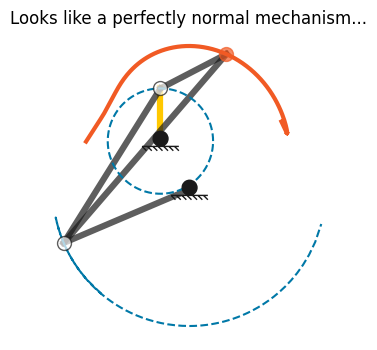

55 of 200 timesteps are NaN (first at timestep 139) -- the mechanism locks partway through the rotation.


In [8]:
# Even a structurally-valid (DOF=1) mechanism can still LOCK: partway through the crank's
# rotation, the geometry can become infeasible (e.g. two circles that need to intersect no
# longer do). Nothing here is structurally wrong -- it only shows up once we actually try to
# move it. Here's a starting position (same structure as our mechanism) that locks:
x0_locking = np.array([[ 0.5478, -0.9209],
                       [-1.8361, -1.9339],
                       [ 1.2531,  1.6510]])

plt.figure(figsize=(4,4))
visualizer(x0_locking, edges, fixed_joints, ax=plt.gca())
plt.title('Looks like a perfectly normal mechanism...')
plt.show()

solution = solver(x0_locking, edges, fixed_joints)
locked_timesteps = np.isnan(solution).any(axis=(0, 2))
print(f'{locked_timesteps.sum()} of {len(locked_timesteps)} timesteps are NaN '
      f'(first at timestep {np.argmax(locked_timesteps)}) -- the mechanism locks partway through the rotation.')

## The Evaluator: Solver, Tools, and DifferentiableTools
The solver we have introduced implements an underlying kinematics engine:

- **`MechanismSolver`**: given a mechanism, solves its full motion &mdash; every joint's position at every timestep. Used for visualization/inspection, and internally by everything below.

We have also built a little more scaffolding to help with actual optimization tasks: 
- **`Tools`**: solves the mechanism (the same solve as above), then compares the target joint's traced curve to a target curve, returning a single distance. No gradient &mdash; the right choice when you only need to *rank/compare* candidates (e.g. a genetic algorithm).
- **`DifferentiableTools`**: the exact same computation as `Tools`, with its gradient (via automatic differentiation) computed too. The right choice when you need a *direction* to improve a design (e.g. gradient descent) &mdash; but that gradient isn't free.

### Speedups
In optimization, we spend a great deal of time designing algorithms that find strong solutions more quickly (in fewer tries). However, it's important to consider that the speed of evaluation also affects how quickly we can find a solution. If we can evaluate solutions 10x faster, we can search for 10x as many iterations and potentially find a much better solution. Thus, it's worth understanding any potential acceleration possible for your design evaluators. 

We'll use the linkage problem to illustrate a few things that commonly affect how fast your computational evaluators run: whether they're **compiled**, whether calls are **batched**, and (specifically for `DifferentiableTools` in this case) whether you're actually asking for a **gradient**. Let's measure each of these one at a time, holding the other two at their best setting (compiled, batched):

In [9]:
import time

# 50 different starting positions for our mechanism
rng = np.random.default_rng(0)
x0_batch = [x0 + rng.uniform(-0.5, 0.5, size=x0.shape) for _ in range(50)]
n_rounds = 5  # e.g. "20 generations" worth of repeated evaluation

def batched_call(tool):
    return tool(x0s=x0_batch, edges=[edges] * 50, fixed_joints=[fixed_joints] * 50,
                target_curve=target_curve, target_idx=[None] * 50)

def looped_call(tool):
    for x in x0_batch:
        tool(x, edges, fixed_joints, target_curve, target_idx=None)

def time_rounds(fn, rounds=n_rounds):
    fn()  # warm up -- pays any one-time compilation cost here, not in the timing below
    t0 = time.time()
    for _ in range(rounds):
        fn()
    return time.time() - t0

# Our default going forward: COMPILED and BATCHED, with the gradient (DifferentiableTools).
grad_tools = DifferentiableTools(scaled=True, device='cpu')
grad_tools.compile()
t_default = time_rounds(lambda: batched_call(grad_tools))
print(f'Default (compiled, batched, with gradient): {t_default:.2f}s for {n_rounds} rounds of 50 evaluations')

Default (compiled, batched, with gradient): 0.30s for 5 rounds of 50 evaluations


In [10]:
# 1) Does compiling matter?
grad_tools_uncompiled = DifferentiableTools(scaled=True, device='cpu')  # .compile() never called
t_uncompiled = time_rounds(lambda: batched_call(grad_tools_uncompiled))
print(f'Uncompiled: {t_uncompiled:.2f}s   -- compiling makes this {t_uncompiled/t_default:.1f}x faster')

Uncompiled: 3.44s   -- compiling makes this 11.4x faster


In [11]:
# 2) Does batching matter?
t_looped = time_rounds(lambda: looped_call(grad_tools))
print(f'Looped (same compiled tool, one mechanism at a time): {t_looped:.2f}s   '
      f'-- batching makes this {t_looped/t_default:.1f}x faster')

Looped (same compiled tool, one mechanism at a time): 0.49s   -- batching makes this 1.6x faster


In [12]:
# 3) Does asking for the gradient cost anything?
tools_only = Tools(scaled=True, device='cpu')
tools_only.compile()
t_nograd = time_rounds(lambda: batched_call(tools_only))
print(f'Tools (no gradient), compiled+batched: {t_nograd:.2f}s   '
      f'-- DifferentiableTools costs {t_default/t_nograd:.1f}x more, for the gradient')

Tools (no gradient), compiled+batched: 0.18s   -- DifferentiableTools costs 1.6x more, for the gradient


So: always compile; batch when you can; and only reach for `DifferentiableTools` (paying for the gradient) when you actually need one &mdash; e.g. for gradient descent, right below. For methods like the genetic algorithm later in this notebook, which only need to *rank* candidates against each other, plain `Tools` is the right (cheaper) choice &mdash; which is exactly what it's used there.

## Gradient-Based Optimization
Now that we have the basics figured out (and already created `grad_tools`, a `DifferentiableTools` instance, above), let's actually optimize. `DifferentiableTools` returns both the curve-matching distance and its gradient with respect to the joint positions. We use `scaled=True` so the distance is shape-only (scale-invariant) &mdash; consistent with treating mechanism scale as fixed by the crank, not something to be matched to an arbitrary target size.

Now let's run this with our current initial positions and see what the output looks like:

Objective (distance to target): 1.4997
x0.shape        = (3, 2)         -- one (x, y) position per free joint (nodes 2, 3, 4)
gradients.shape = (3, 2)         -- one (x, y) gradient per free joint, same order as x0
gradients =
[[ 0.04981067 -0.03987896]
 [-0.5652381   0.06372615]
 [ 0.59358245  0.49267915]]

Each row says "moving this joint this way increases the distance the most."
Gradient DESCENT steps OPPOSITE that direction, since we want to minimize distance.


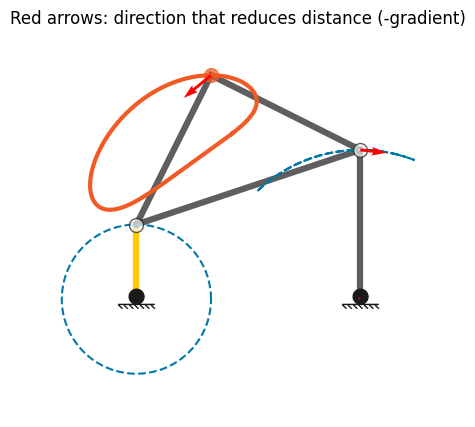

In [13]:
distance, gradients = grad_tools(x0, edges, fixed_joints, target_curve, target_idx=None)

print(f'Objective (distance to target): {distance:.4f}')
print(f'x0.shape        = {x0.shape}         -- one (x, y) position per free joint (nodes 2, 3, 4)')
print(f'gradients.shape = {gradients.shape}         -- one (x, y) gradient per free joint, same order as x0')
print(f'gradients =\n{gradients}')
print('\nEach row says "moving this joint this way increases the distance the most."')
print('Gradient DESCENT steps OPPOSITE that direction, since we want to minimize distance.')

# Visualize this: draw the mechanism, then draw a red arrow at each free joint pointing in
# the direction that REDUCES distance (the negative gradient) -- exactly the direction
# gradient descent is about to step in.
plt.figure(figsize=(5,5))
ax = visualizer(x0, edges, fixed_joints, ax=plt.gca())
ax.quiver(x0[:,0], x0[:,1], -gradients[:,0], -gradients[:,1], color='red', angles='xy', zorder=15)
plt.title('Red arrows: direction that reduces distance (-gradient)')
plt.show()

In [14]:
# What does an optimizer actually see when it hits one of the constraint violations from
# earlier? Let's check with the locking configuration:
distance, gradients = grad_tools(x0_locking, edges, fixed_joints, target_curve, target_idx=None)
print(f'distance={distance}, gradients=\n{gradients}')

distance=inf, gradients=
[[0. 0.]
 [0. 0.]
 [0. 0.]]


Now we can perform a simple gradient descent for this mechanism until either convergence or until the mechanism locks. If a step leads to a locking mechanism, the objective becomes infinite (and, as we just saw, the gradient comes back as exactly zero rather than NaN), and we stop and roll back to the last valid step:

In [15]:
# set the optimization parameters
step_size = 1e-2
max_iters = 500

x = x0.copy()

# Store the objective values and node positions at each iteration to plot/animate later
objective_history = []
x_history = [] 

progress_bar = trange(max_iters)
for step in progress_bar:
    objective, gradients = grad_tools(x, edges, fixed_joints, target_curve, target_idx=None)

    if np.isinf(objective) or np.any(np.isnan(gradients)):
        print('Mechanism locked. Stopping optimization.')
        break #exit loop if the mechanism locks (infeasible geometry)

    objective_history.append(float(objective))
    x_history.append(x.copy())

    x = x - step_size * gradients

    progress_bar.set_postfix({'Objective': float(objective)})

  0%|          | 0/500 [00:00<?, ?it/s]

We see that the distance objective is much smaller at the end of this optimization. Let's visualize the mechanism's evolution and compare the curves:

In [16]:
# animate the evolution of the mechanism
from matplotlib import animation
from IPython.display import HTML

# Solve every recorded configuration in a single BATCHED call (much faster one by one)
n_frames_total = len(x_history)
batch_solutions = solver(x_history, [edges] * n_frames_total, [fixed_joints] * n_frames_total)
all_positions = np.concatenate([np.asarray(s).reshape(-1, 2) for s in batch_solutions], axis=0)
margin = 0.5
xlim = (all_positions[:,0].min() - margin, all_positions[:,0].max() + margin)
ylim = (all_positions[:,1].min() - margin, all_positions[:,1].max() + margin)

# Animating every single iteration is slow to render for little visual benefit (consecutive
# gradient steps look nearly identical) -- show every 5th iteration instead.
stride = 5
frame_indices = list(range(0, n_frames_total, stride))

fig, ax = plt.subplots(figsize=(5,5))

def update(i):
    frame = frame_indices[i]
    ax.clear()
    visualizer(x_history[frame], edges, fixed_joints, ax=ax)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('equal', adjustable='box')
    ax.axis('off')
    ax.set_title(f'Iteration {frame+1}/{n_frames_total}, Objective: {objective_history[frame]:.4f}')

ani = animation.FuncAnimation(fig, update, frames=len(frame_indices), interval=200)
plt.close(fig)
HTML(ani.to_jshtml(fps=25, default_mode='once'))

Now let's plot how the objective changed during optimization:

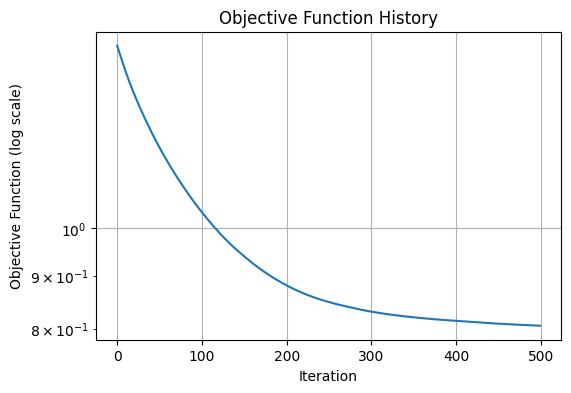

In [17]:
plt.figure(figsize=(6,4))
plt.plot(objective_history)
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Objective Function (log scale)')
plt.title('Objective Function History')
plt.grid()
plt.show()

...and compare curves before and after optimization:

Initial Distance between curves: 1.4997
Optimized Distance between curves: 0.8057


Text(0.5, 0.98, 'After Optimization')

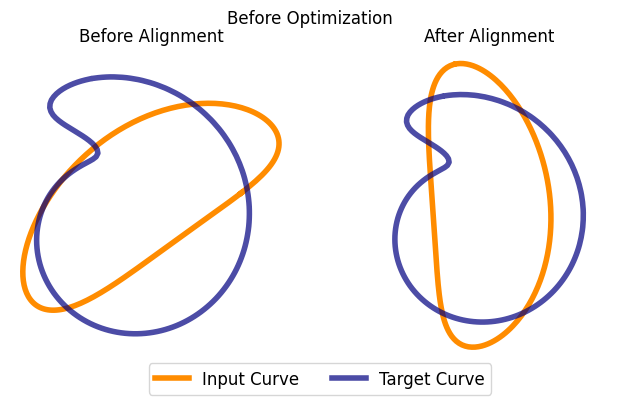

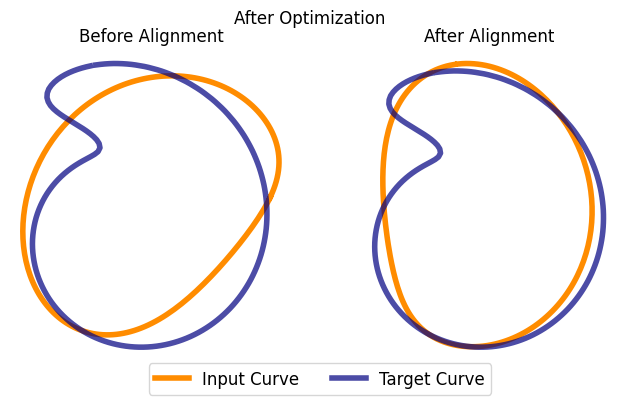

In [18]:
initial_curve = solver(x0, edges, fixed_joints)[-1]
optimized_curve = solver(x_history[-1], edges, fixed_joints)[-1]

_, _, initial_distance = curve_processor.optimal_alignment(initial_curve, target_curve)
_, _, optimized_distance = curve_processor.optimal_alignment(optimized_curve, target_curve)

print(f'Initial Distance between curves: {float(initial_distance):.4f}')
print(f'Optimized Distance between curves: {float(optimized_distance):.4f}')

curve_processor.visualize_alignment(initial_curve, target_curve)
plt.suptitle('Before Optimization')

curve_processor.visualize_alignment(optimized_curve, target_curve)
plt.suptitle('After Optimization')

We can see that the curves are more similar to each other after optimization, but this is far from perfect &mdash; it's a hard problem, and from this starting point this is roughly where gradient descent takes us.

## Genetic Algorithm
We saw how, given a starting point, we can run local gradient-based optimization to try to match our target curve. But what if we don't know a good starting point? Gradient descent can also get stuck in poor local optima. Another approach we discussed in class is the **genetic algorithm (GA)**. Here we will run the NSGA-II algorithm (available through the `pymoo` package) on the same single-objective problem: minimizing curve distance.

### Setting Up the GA
We must first define the problem within `pymoo`. In `pymoo`, a `Problem` just describes what to optimize: how many design variables (`n_var`), their bounds (`xl`/`xu`), how many objectives (`n_obj`), and how to *evaluate* candidate designs (the `_evaluate` method below). As we just saw, batching evaluations together is much faster than one at a time -- so `_evaluate` receives the *entire population* at once (`X`, shape `(pop_size, n_var)`), and we hand all of it to `PROBLEM_TOOLS` in a single call, rather than evaluating one design per call. Nodes 0 and 1 (the crank) are fixed and not part of `x0`, so we only have $x,y$ positions of the remaining 3 nodes as design variables (2x3=6 parameters), a single objective (curve distance), and bounds of -4.0 to 4.0 on the parameters.

In [19]:
# pymoo imports
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PolynomialMutation
from pymoo.optimize import minimize

First we define the problem in pymoo, using the `Tools` class (the non-differentiable counterpart to `DifferentiableTools` &mdash; GA doesn't need gradients):

In [20]:
PROBLEM_TOOLS = Tools(scaled=True, device='cpu') # defined outside the class due to pymoo deepcopy limitations
PROBLEM_TOOLS.compile() # compile the functions for faster runs

class mechanism_optimization(Problem):

    # When initializing, get the mechanism structure being optimized
    # (not the initial positions, since those are what we're trying to find)
    def __init__(self, n_nodes, edges, fixed_joints, target_curve):
        # n_var = number of parameters (number of FREE nodes * 2), n_obj = number of objectives,
        # xl/xu = lower/upper bound for the parameters
        super().__init__(n_var=n_nodes * 2, n_obj=1, xl=-4.0, xu=4.0)

        # Store mechanism information for later
        self.edges = edges
        self.fixed_joints = fixed_joints
        self.n_nodes = n_nodes

        # Store the target curve point cloud
        self.target_curve = target_curve

    def _evaluate(self, X, out, *args, **kwargs):
        # X is the WHOLE population at once: shape (pop_size, n_var). Reshape each row back
        # into a (n_nodes, 2) array of joint positions, and evaluate all of them in a single
        # batched call -- exactly the batching we just measured above.
        n_pop = X.shape[0]
        x0s = [row.reshape(self.n_nodes, 2) for row in X]

        distances = PROBLEM_TOOLS(x0s=x0s,
                                   edges=[self.edges] * n_pop,
                                   fixed_joints=[self.fixed_joints] * n_pop,
                                   target_curve=self.target_curve,
                                   target_idx=[None] * n_pop)

        out["F"] = np.reshape(distances, (-1, 1))

Now let's set up NSGA-II and run it:

In [21]:
# Setup an instance of our problem
n_nodes = x0.shape[0]  # number of free joints (nodes 2+)
problem = mechanism_optimization(n_nodes, edges, fixed_joints, target_curve)

print(f'n_var = {problem.n_var}  -- {problem.n_nodes} non-crank joints x 2 (x, y) coordinates each')
print(f'xl = {problem.xl}\nxu = {problem.xu}  -- every variable is bounded between these')

# Setup the algorithm
algorithm = NSGA2(pop_size=32,
                  sampling=FloatRandomSampling(),
                  crossover=SBX(prob=1.0, eta=3.0),
                  mutation=PolynomialMutation(eta=3.0, prob=0.05),
                  eliminate_duplicates=True)

results = minimize(problem,
                   algorithm,
                   ('n_gen', 50),
                   verbose=True,
                   save_history=True,
                   seed=3)

print(f'\nresults.X.shape = {results.X.shape}  -- the best design(s) found, each a flattened length-{problem.n_var} vector')
print(f'results.F.shape = {results.F.shape}  -- their objective value(s) (just distance, since n_obj=1)')

n_var = 6  -- 3 non-crank joints x 2 (x, y) coordinates each
xl = [-4. -4. -4. -4. -4. -4.]
xu = [4. 4. 4. 4. 4. 4.]  -- every variable is bounded between these


c:\Users\Lyler\miniforge3\envs\CP1\lib\site-packages\pymoo\operators\survival\rank_and_crowding\metrics.py:97: RuntimeWarning: invalid value encountered in subtract
  dist = np.row_stack([F, np.full(n_obj, np.inf)]) - np.row_stack([np.full(n_obj, -np.inf), F])
c:\Users\Lyler\miniforge3\envs\CP1\lib\site-packages\pymoo\operators\survival\rank_and_crowding\metrics.py:100: RuntimeWarning: invalid value encountered in subtract
  norm = np.max(F, axis=0) - np.min(F, axis=0)


n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       32 |      1 |             - |             -
     2 |       64 |      1 |  0.0068230033 |         ideal
     3 |       96 |      1 |  0.000000E+00 |             f
     4 |      128 |      1 |  0.0776726007 |         ideal
     5 |      160 |      1 |  0.0380422473 |         ideal
     6 |      192 |      1 |  0.0052456260 |         ideal
     7 |      224 |      1 |  0.0000439882 |             f
     8 |      256 |      1 |  0.0130614638 |         ideal
     9 |      288 |      1 |  0.0235955715 |         ideal
    10 |      320 |      1 |  0.0019102693 |             f
    11 |      352 |      1 |  0.0467077494 |         ideal
    12 |      384 |      1 |  0.000000E+00 |             f
    13 |      416 |      1 |  0.0142451525 |         ideal
    14 |      448 |      1 |  0.000000E+00 |             f
    15 |      480 |      1 |  0.000000E+00 |             f
    16 |      512 |      1 |  0.0006474257 |            

Because we passed `save_history=True`, `results.history` recorded the entire population at every generation. Let's use that to see how the *best* objective in the population improved generation by generation -- this is what "the GA is searching" actually looks like:

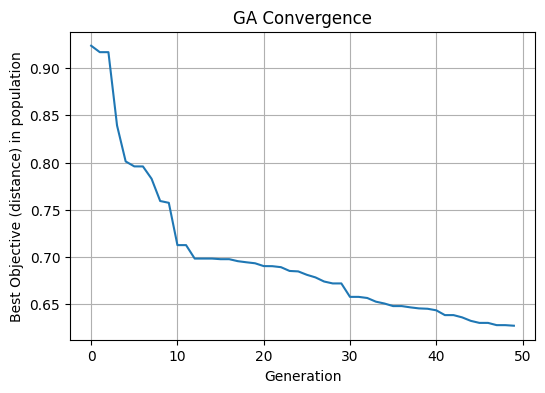

In [22]:
best_per_gen = [gen.pop.get("F").min() for gen in results.history]

plt.figure(figsize=(6, 4))
plt.plot(best_per_gen)
plt.xlabel('Generation')
plt.ylabel('Best Objective (distance) in population')
plt.title('GA Convergence')
plt.grid()
plt.show()

We will now visualize the populations in each generation by only displaying the nodes in different colors:

In [23]:
fig, ax = plt.subplots(figsize=(5,5))

def animate(i):
    ax.clear()
    population = results.history[i].pop.get("X")
    for m in population:
        inits = np.reshape(m, [-1,2])
        ax.scatter(inits[:,0], inits[:,1])
    # Fix the view to the GA's actual search bounds instead of autoscaling to each frame's
    # data -- otherwise a tightly converged population re-zooms to fill the frame every time,
    # hiding just how much the population has actually contracted.
    ax.set_xlim(problem.xl[0], problem.xu[0])
    ax.set_ylim(problem.xl[0], problem.xu[0])
    ax.set_aspect('equal')
    ax.set_title(f'Generation {i+1}/{len(results.history)}')

ani = animation.FuncAnimation(fig, animate, frames=len(results.history))
plt.close(fig)
HTML(ani.to_jshtml(fps=5, default_mode='once'))

Note that the population is initially diverse and, as the genetic algorithm progresses, becomes more and more uniform &mdash; by the end, designs in the population are almost identical. This is typical of algorithms with high selectivity of superior-performing population members.

Now let's grab the best solution found and visualize it:

<Axes: >

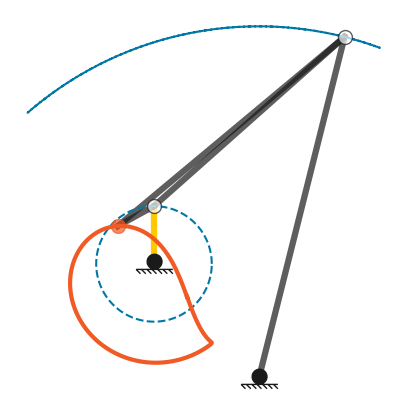

In [24]:
if results.X.ndim > 1:
    best_x0 = results.X[0].reshape(-1,2)
else:
    best_x0 = results.X.reshape(-1,2)

plt.figure(figsize=(5,5))
visualizer(best_x0, edges, fixed_joints, ax=plt.gca())

Initial Distance between curves: 1.4997
GA-Optimized Distance between curves: 0.6272


Text(0.5, 0.98, 'After GA Optimization')

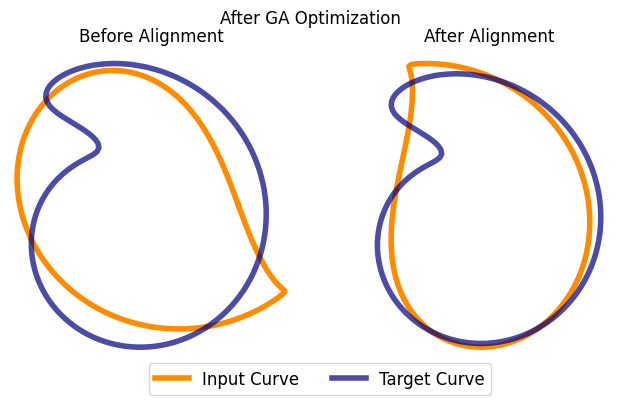

In [25]:
optimized_curve = solver(best_x0, edges, fixed_joints)[-1]

_, _, initial_distance = curve_processor.optimal_alignment(curve, target_curve)
_, _, optimized_distance = curve_processor.optimal_alignment(optimized_curve, target_curve)

print(f'Initial Distance between curves: {float(initial_distance):.4f}')
print(f'GA-Optimized Distance between curves: {float(optimized_distance):.4f}')

curve_processor.visualize_alignment(optimized_curve, target_curve)
plt.suptitle('After GA Optimization')

We see that, because the genetic algorithm mutates the mechanism and randomly changes the configuration, it can escape a local feasible region and find a better one &mdash; something plain gradient descent from a single starting point cannot do. Nonetheless, there is room for improvement, and you'll hopefully achieve it in CP1!

## Reflection

**Reflection 1: Start gradient-based optimization from the solution the GA provided. Does gradient-based optimization improve the GA solution? If so, by how much? (write your code below and explain what it's doing) (30s)**

Hint: reuse the gradient descent loop from earlier, but start from `best_x0` instead of `x0`. Try experimenting with the step size and number of iterations &mdash; there's a tradeoff (too large a step size and optimization may be unstable or quickly hit a constraint; too small and you won't get far in a reasonable number of iterations), so it's worth trying a few combinations.

In [26]:
## YOUR CODE HERE
## HINT: Reuse the gradient descent code above, but start from best_x0 and adjust step size / iteration count.


**Reflection 2: Up to this point, we used the original four-bar mechanism we defined. But this mechanism is simple and cannot solve more complex target curves. Come up with a different, more complex mechanism configuration and try running the algorithms again. Explain your observations (30s)**

In [27]:
# Here is an example mechanism that is more complex. If you couldn't come up with your own, you can use this one.
# As always, nodes 0 and 1 are the fixed crank (0,0)/(0,1) and are not part of x0, edges, or fixed_joints.

x0_large = np.array([[3.5205, -0.0685],
               [3.589 ,  1.8082],
               [1.4658, -2.274 ],
               [3.4932, -1.5753],
               [6.589 ,  2.2055],
               [3.589 ,  3.2192],
               [0.0959,  3.3973]])

edges_large = np.array([[1,3],
                  [1,4],
                  [1,8],
                  [2,3],
                  [3,4],
                  [3,5],
                  [4,5],
                  [5,7],
                  [6,7],
                  [7,8]])

fixed_joints_large = np.array([2,6])

## Next Up: Challenge Problem 1
In this demo, the mechanism's *structure* (how many joints, how they connect) was always something we chose ahead of time &mdash; only the joint *positions* were design variables. In CP1 you'll extend this in two ways: letting the optimizer search over mechanism *structure* itself, and introducing a second objective (mechanism **complexity**, i.e. how many joints a mechanism uses) alongside curve distance.